<a href="https://colab.research.google.com/github/goelshreya3001-droid/Academic-Project/blob/main/house_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

House_price_prediction model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving house_price_prediction_12000.csv to house_price_prediction_12000 (1).csv


In [3]:
df = pd.read_csv("house_price_prediction_12000.csv")

In [4]:
df.head()

,area_sqft,bedrooms,bathrooms,stories,age_years,parking_spaces,distance_to_city_km,location,furnished,property_type,price
0,3674,4,4,3,14,1,10.8,Bangalore,Unfurnished,Apartment,17445000
1,4007,4,2,3,0,3,25.3,Mumbai,Unfurnished,Apartment,26429000
2,1360,2,4,3,5,3,18.8,Lucknow,Furnished,Villa,7160000
3,1794,3,4,1,21,0,20.8,Hyderabad,Semi-Furnished,Villa,9299000
4,1630,2,1,4,16,3,15.6,Pune,Semi-Furnished,Independent House,8068000


In [5]:
df.shape

(12000, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   area_sqft            12000 non-null  int64  
 1   bedrooms             12000 non-null  int64  
 2   bathrooms            12000 non-null  int64  
 3   stories              12000 non-null  int64  
 4   age_years            12000 non-null  int64  
 5   parking_spaces       12000 non-null  int64  
 6   distance_to_city_km  12000 non-null  float64
 7   location             12000 non-null  object 
 8   furnished            12000 non-null  object 
 9   property_type        12000 non-null  object 
 10  price                12000 non-null  int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 1.0+ MB


In [7]:
df.describe()

,area_sqft,bedrooms,bathrooms,stories,age_years,parking_spaces,distance_to_city_km,price
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,1.200000e+04
mean,2508.517750,2.985250,2.508167,2.487667,15.196417,1.504167,15.588708,1.299017e+07
std,1155.160173,1.420575,1.124221,1.116819,9.007687,1.117551,8.386847,7.062119e+06
min,500.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,5.160000e+05
25%,1497.750000,2.000000,1.000000,1.000000,7.000000,1.000000,8.300000,7.376750e+06
50%,2503.000000,3.000000,3.000000,3.000000,15.000000,2.000000,15.600000,1.187900e+07
75%,3510.000000,4.000000,4.000000,3.000000,23.000000,3.000000,22.900000,1.753225e+07
max,4500.000000,5.000000,4.000000,4.000000,30.000000,3.000000,30.000000,4.381000e+07


In [8]:
df.describe(include="object")

,location,furnished,property_type
count,12000,12000,12000
unique,10,3,3
top,Gurgaon,Semi-Furnished,Apartment
freq,1254,5386,6547


Finding missing values


In [9]:
df.isnull().sum()

,0
area_sqft,0
bedrooms,0
bathrooms,0
stories,0
age_years,0
parking_spaces,0
distance_to_city_km,0
location,0
furnished,0
property_type,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["price"].describe()

,price
count,1.200000e+04
mean,1.299017e+07
std,7.062119e+06
min,5.160000e+05
25%,7.376750e+06
50%,1.187900e+07
75%,1.753225e+07
max,4.381000e+07


Graphical reperesentation

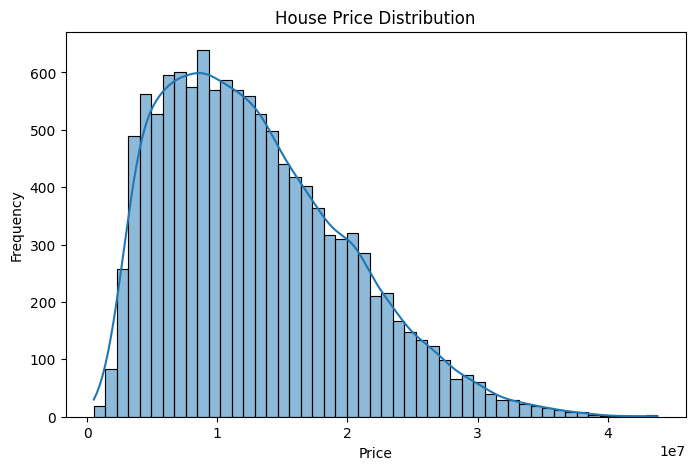

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

EDA

In [13]:
X = df.drop("price", axis=1)
y = df["price"]

In [14]:
X.head()

,area_sqft,bedrooms,bathrooms,stories,age_years,parking_spaces,distance_to_city_km,location,furnished,property_type
0,3674,4,4,3,14,1,10.8,Bangalore,Unfurnished,Apartment
1,4007,4,2,3,0,3,25.3,Mumbai,Unfurnished,Apartment
2,1360,2,4,3,5,3,18.8,Lucknow,Furnished,Villa
3,1794,3,4,1,21,0,20.8,Hyderabad,Semi-Furnished,Villa
4,1630,2,1,4,16,3,15.6,Pune,Semi-Furnished,Independent House


In [15]:
y.head()

,price
0,17445000
1,26429000
2,7160000
3,9299000
4,8068000


In [16]:
X.select_dtypes(include="object").columns

Index(['location', 'furnished', 'property_type'], dtype='object')

In [17]:
X = pd.get_dummies(X, drop_first=True)

In [18]:
X.head()

,area_sqft,bedrooms,bathrooms,stories,age_years,parking_spaces,distance_to_city_km,location_Delhi,location_Ghaziabad,location_Gurgaon,location_Hyderabad,location_Jaipur,location_Lucknow,location_Mumbai,location_Noida,location_Pune,furnished_Semi-Furnished,furnished_Unfurnished,property_type_Independent House,property_type_Villa
0,3674,4,4,3,14,1,10.8,False,False,False,False,False,False,False,False,False,False,True,False,False
1,4007,4,2,3,0,3,25.3,False,False,False,False,False,False,True,False,False,False,True,False,False
2,1360,2,4,3,5,3,18.8,False,False,False,False,False,True,False,False,False,False,False,False,True
3,1794,3,4,1,21,0,20.8,False,False,False,True,False,False,False,False,False,True,False,False,True
4,1630,2,1,4,16,3,15.6,False,False,False,False,False,False,False,False,True,True,False,True,False


In [19]:
X.shape

(12000, 20)

Train_Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (9600, 20)
Testing data: (2400, 20)


LINEAR REGRESSION

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
model = LinearRegression()

In [24]:
model.fit(X_train, y_train)

LinearRegression()

In [25]:
y_pred = model.predict(X_test)

In [26]:
y_pred[:10]

array([17591073.1748326 , 20615841.34017435, 11581148.76424265,
       11775322.34567214,  3062693.81020046, 14816939.48216579,
       17179650.79024061, 14705130.30078629,  8081393.48896203,
        9812380.52849761])

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 1319044.9952893765
RMSE: 1810957.9111353324
R2 Score: 0.9373500294654588


Train usingdecision tree

In [28]:
from sklearn.tree import DecisionTreeRegressor

In [29]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

In [30]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [31]:
dt_pred = dt_model.predict(X_test)

In [32]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

Decision Tree Results
MAE : 893777.5
RMSE: 1189197.5662885737
R2 Score: 0.9729845515722961


Comparison with regression


In [33]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

Decision Tree Results
MAE : 893777.5
RMSE: 1189197.5662885737
R2 Score: 0.9729845515722961


In [34]:
print("Linear Regression R2 :", r2)
print("Decision Tree R2     :", dt_r2)

Linear Regression R2 : 0.9373500294654588
Decision Tree R2     : 0.9729845515722961


Random Forest

In [35]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [37]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [38]:
rf_pred = rf_model.predict(X_test)

In [39]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MAE : 604615.05
RMSE: 808577.8811241685
R2 Score: 0.9875104189374294


Comparison of all linear regression, decision tree and random forest

In [40]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2 Score": [
        r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.319045e+06,1.810958e+06,0.937350
1,Decision Tree,8.937775e+05,1.189198e+06,0.972985
2,Random Forest,6.046151e+05,8.085779e+05,0.987510


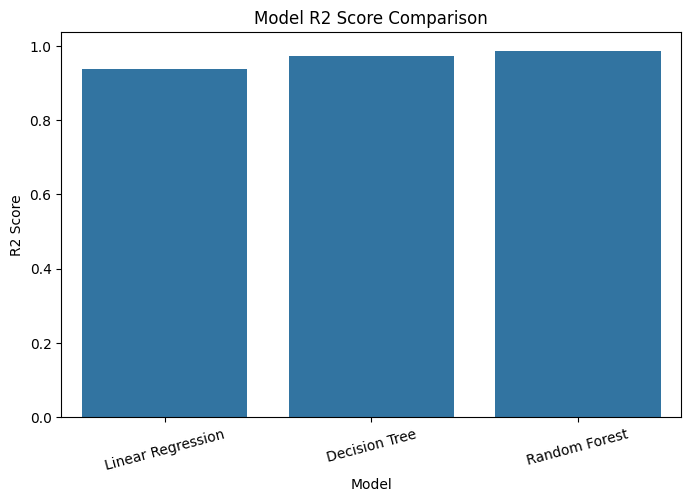

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Model R2 Score Comparison")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.show()

Feature importance

In [42]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,area_sqft,0.675734
13,location_Mumbai,0.093075
9,location_Gurgaon,0.045849
7,location_Delhi,0.042383
19,property_type_Villa,0.028523
11,location_Jaipur,0.023681
12,location_Lucknow,0.023397
8,location_Ghaziabad,0.016405
17,furnished_Unfurnished,0.015845
10,location_Hyderabad,0.007193


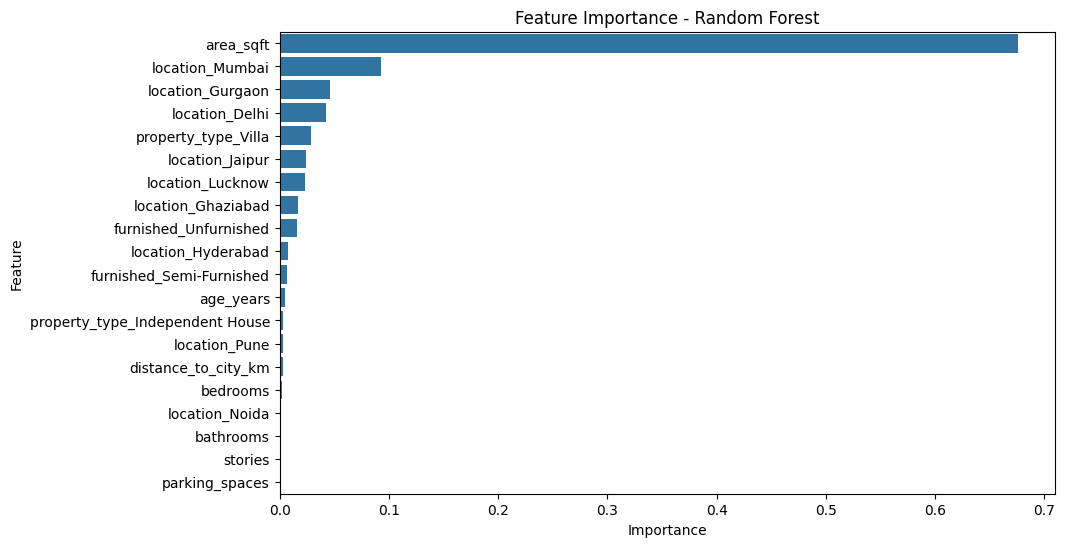

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

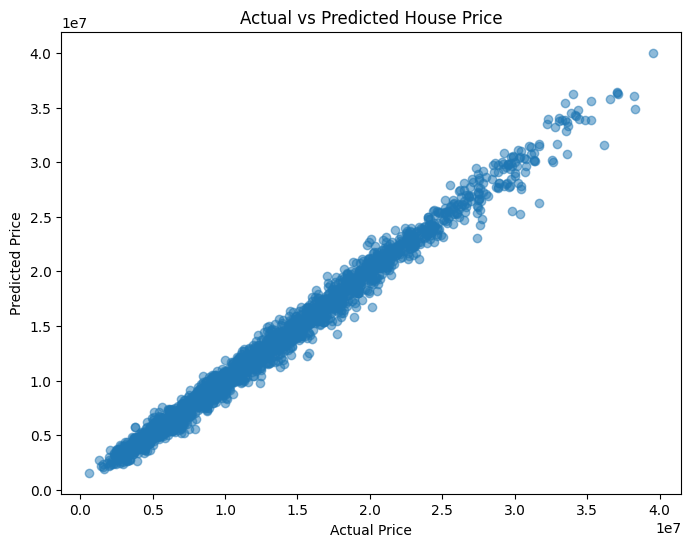

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")

plt.show()

Prediction of new house price

In [45]:
new_house = pd.DataFrame({
    "area_sqft": [2000],
    "bedrooms": [3],
    "bathrooms": [2],
    "stories": [2],
    "age_years": [5],
    "parking_spaces": [2],
    "distance_to_city_km": [8],
    "location": ["Noida"],
    "furnished": ["Semi-Furnished"],
    "property_type": ["Apartment"]
})

In [46]:
new_house = pd.get_dummies(new_house, drop_first=True)

In [47]:
new_house = new_house.reindex(
    columns=X.columns,
    fill_value=False
)

In [48]:
predicted_price = rf_model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 11446080.0


In [49]:
print(f"Predicted House Price: ₹{predicted_price[0]:,.0f}")

Predicted House Price: ₹11,446,080
